In [1]:
import os
import json
import pickle
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from Functions import (cost_per_sample, generate_legal_neighbors, barker, compute_A)

# Slightly larger default axis label / tick sizes for every plot in this notebook
plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [2]:
# ---- Backup / output setup ----
# Everything (checkpoints, final arrays, figures) gets written here, timestamped,
# so a crashed kernel or an overwritten variable never costs you the whole run.
RUN_ID = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"run_{RUN_ID}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "checkpoint.pkl")

print(f"Output directory: {OUTPUT_DIR}")

def save_figure(fig, name):
    """Save a figure as both PNG (quick viewing) and SVG (vector, for editing/papers)."""
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.svg"), bbox_inches="tight")

def save_checkpoint(state):
    """Overwrite the checkpoint file with the current training state.
    Called periodically during the loop so a crash mid-run doesn't lose everything."""
    tmp_path = CHECKPOINT_PATH + ".tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(state, f)
    os.replace(tmp_path, CHECKPOINT_PATH)  # atomic on POSIX: avoids a half-written file

Output directory: run_20260717_000357


In [3]:
#function
def RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks):
    d = d0.copy()
    E_current = cost_per_sample(Gamma, A, H, d)
    grad_logP = np.zeros(num_blocks)

    for t in range(num_time_steps):
        neighbors = generate_legal_neighbors(d)
        if len(neighbors) == 0:
            break

        block = t // block_size
        beta_t = beta_schedule[block]
        j = np.random.randint(len(neighbors))
        d_prime = neighbors[j]
        E_prime = cost_per_sample(Gamma, A, H, d_prime)
        deltaE = E_prime - E_current

        A_accept = barker(deltaE, beta_t)
        u = np.random.uniform(0, 1)
        if u < A_accept:
            grad_logP[block] += -deltaE / (1 + np.exp(-beta_t * deltaE))
            d, E_current = d_prime, E_prime
        else:
            grad_logP[block] += deltaE / (1 + np.exp(beta_t * deltaE))

    return d, E_current, grad_logP


def run_experiment(d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks):
    _, E_final, grad_logP = RL_trajectory_schedule(
        d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks
    )
    return E_final, grad_logP


def grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps,
                                num_independent_experiments, block_size, num_blocks):
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment)(
            d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks)
        for _ in range(num_independent_experiments)
    )

    costs = np.zeros(num_independent_experiments)
    grad_matrix = np.zeros((num_independent_experiments, num_blocks))

    for i, (E_final, grad_logP) in enumerate(results):
        costs[i] = E_final
        grad_matrix[i] = grad_logP

    # baseline-subtracted (variance-reduced) REINFORCE estimator
    baseline = np.mean(costs)
    grad_beta_schedule = np.mean((costs - baseline)[:, None] * grad_matrix, axis=0)

    return costs, grad_beta_schedule


def update_beta_schedule(beta_schedule, grad_beta_schedule, learning_rate):
    beta_schedule = beta_schedule - learning_rate * grad_beta_schedule
    return np.clip(beta_schedule, 0.0, None)


def evaluate_schedule(d0, Gamma, beta_schedule, num_time_steps, num_eval_experiments,
                       block_size, num_blocks):
    """Run fresh, independent trajectories under a fixed schedule (no gradient
    tracking needed) and report the resulting energy distribution. Used for a
    held-out comparison that isn't contaminated by the trajectories used to
    fit beta_schedule."""
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment)(
            d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks)
        for _ in range(num_eval_experiments)
    )
    costs = np.array([E_final for E_final, _ in results])
    return costs

In [4]:
#parameters
H = 1
P = 0
Gamma = [H,P,H,P,P,H,H,P,H,P,P,H,P,H,H,P,P,H,P,H]  # 20-bead sequence
assert len(Gamma) == 20
d0 = [1] * (len(Gamma) - 1)  # initial fold: straight chain

num_time_steps = 10000
num_independent_experiments = 50
learning_rate = 0.1
num_iterations = 1000
block_size = 100
num_blocks = num_time_steps // block_size

num_eval_experiments = 500  # held-out trajectories for final evaluation

snapshot_every = 100     # iterations between recorded schedule snapshots (for the evolution plot)
checkpoint_every = 20    # iterations between on-disk checkpoints (backup safety net)

beta_schedule = np.full(num_blocks, 0.1)
print(f"num_blocks = {num_blocks}, block_size = {block_size}")

num_blocks = 100, block_size = 100


In [5]:
# training loop
cost_history = []
schedule_snapshots = []
best_beta_schedule = beta_schedule.copy()
best_cost_so_far = np.inf

try:
    for iteration in range(num_iterations):
        costs, grad = grad_expectedcost_schedule(
            d0, Gamma, beta_schedule, num_time_steps,
            num_independent_experiments, block_size, num_blocks
        )
        beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
        mean_cost = np.mean(costs)
        cost_history.append(mean_cost)

        if mean_cost < best_cost_so_far:
            best_cost_so_far = mean_cost
            best_beta_schedule = beta_schedule.copy()

        if iteration % snapshot_every == 0:
            schedule_snapshots.append(beta_schedule.copy())

        if iteration % checkpoint_every == 0:
            save_checkpoint({
                "iteration": iteration,
                "beta_schedule": beta_schedule,
                "best_beta_schedule": best_beta_schedule,
                "best_cost_so_far": best_cost_so_far,
                "cost_history": cost_history,
                "schedule_snapshots": schedule_snapshots,
                "Gamma": Gamma,
                "d0": d0,
                "num_time_steps": num_time_steps,
                "block_size": block_size,
                "num_blocks": num_blocks,
            })

        if iteration % 20 == 0:
            print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
                  f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={mean_cost:.4f}")

except KeyboardInterrupt:
    print("Training interrupted -- saving current state to checkpoint before stopping.")
    save_checkpoint({
        "iteration": iteration,
        "beta_schedule": beta_schedule,
        "best_beta_schedule": best_beta_schedule,
        "best_cost_so_far": best_cost_so_far,
        "cost_history": cost_history,
        "schedule_snapshots": schedule_snapshots,
        "Gamma": Gamma,
        "d0": d0,
        "num_time_steps": num_time_steps,
        "block_size": block_size,
        "num_blocks": num_blocks,
    })
    raise

# final checkpoint after a clean finish
save_checkpoint({
    "iteration": num_iterations - 1,
    "beta_schedule": beta_schedule,
    "best_beta_schedule": best_beta_schedule,
    "best_cost_so_far": best_cost_so_far,
    "cost_history": cost_history,
    "schedule_snapshots": schedule_snapshots,
    "Gamma": Gamma,
    "d0": d0,
    "num_time_steps": num_time_steps,
    "block_size": block_size,
    "num_blocks": num_blocks,
})
print("Training complete. Checkpoint saved to", CHECKPOINT_PATH)

Iter    0  beta[0]=0.0630  beta[-1]=0.1578  avg cost=-0.8200
Iter   20  beta[0]=0.1205  beta[-1]=2.4489  avg cost=-3.3800
Iter   40  beta[0]=0.1554  beta[-1]=3.5332  avg cost=-4.0400
Iter   60  beta[0]=0.4653  beta[-1]=3.9884  avg cost=-4.6000
Iter   80  beta[0]=0.5673  beta[-1]=4.2216  avg cost=-4.5000
Iter  100  beta[0]=0.6912  beta[-1]=4.5111  avg cost=-4.7600
Iter  120  beta[0]=0.5440  beta[-1]=4.6840  avg cost=-5.1000
Iter  140  beta[0]=0.6036  beta[-1]=4.8388  avg cost=-4.9400
Iter  160  beta[0]=0.5676  beta[-1]=4.9814  avg cost=-5.1000
Iter  180  beta[0]=0.3871  beta[-1]=5.0234  avg cost=-5.0600
Iter  200  beta[0]=0.2841  beta[-1]=5.0621  avg cost=-5.1600
Iter  220  beta[0]=0.4852  beta[-1]=5.1824  avg cost=-5.0200
Iter  240  beta[0]=0.4345  beta[-1]=5.2556  avg cost=-5.1000
Iter  260  beta[0]=0.6500  beta[-1]=5.3152  avg cost=-5.1000
Iter  280  beta[0]=0.5087  beta[-1]=5.4510  avg cost=-5.1600
Iter  300  beta[0]=0.4166  beta[-1]=5.5316  avg cost=-5.6600
Iter  320  beta[0]=0.799

FileNotFoundError: [Errno 2] No such file or directory: 'run_20260716_194049\\checkpoint.pkl.tmp'

In [5]:
import pickle, os

CHECKPOINT_PATH = os.path.join("run_20260716_194049", "checkpoint.pkl")  # your actual folder
with open(CHECKPOINT_PATH, "rb") as f:
    state = pickle.load(f)

beta_schedule = state["beta_schedule"]
best_beta_schedule = state["best_beta_schedule"]
best_cost_so_far = state["best_cost_so_far"]
cost_history = state["cost_history"]
schedule_snapshots = state["schedule_snapshots"]
iteration = state["iteration"]

print(f"Restored from iteration {iteration}, {len(cost_history)} cost entries so far")

Restored from iteration 440, 441 cost entries so far


In [6]:
start_iteration = iteration + 1  # 'iteration' still holds the last completed step (~340-359)
print(f"Resuming from iteration {start_iteration} up to {num_iterations}")

try:
    for iteration in range(start_iteration, num_iterations):
        costs, grad = grad_expectedcost_schedule(
            d0, Gamma, beta_schedule, num_time_steps,
            num_independent_experiments, block_size, num_blocks
        )
        beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
        mean_cost = np.mean(costs)
        cost_history.append(mean_cost)

        if mean_cost < best_cost_so_far:
            best_cost_so_far = mean_cost
            best_beta_schedule = beta_schedule.copy()

        if iteration % snapshot_every == 0:
            schedule_snapshots.append(beta_schedule.copy())

        if iteration % checkpoint_every == 0:
            save_checkpoint({
                "iteration": iteration,
                "beta_schedule": beta_schedule,
                "best_beta_schedule": best_beta_schedule,
                "best_cost_so_far": best_cost_so_far,
                "cost_history": cost_history,
                "schedule_snapshots": schedule_snapshots,
                "Gamma": Gamma,
                "d0": d0,
                "num_time_steps": num_time_steps,
                "block_size": block_size,
                "num_blocks": num_blocks,
            })

        if iteration % 20 == 0:
            print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
                  f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={mean_cost:.4f}")

except KeyboardInterrupt:
    print("Interrupted again -- saving checkpoint.")
    save_checkpoint({
        "iteration": iteration, "beta_schedule": beta_schedule,
        "best_beta_schedule": best_beta_schedule, "best_cost_so_far": best_cost_so_far,
        "cost_history": cost_history, "schedule_snapshots": schedule_snapshots,
        "Gamma": Gamma, "d0": d0, "num_time_steps": num_time_steps,
        "block_size": block_size, "num_blocks": num_blocks,
    })
    raise

save_checkpoint({
    "iteration": num_iterations - 1, "beta_schedule": beta_schedule,
    "best_beta_schedule": best_beta_schedule, "best_cost_so_far": best_cost_so_far,
    "cost_history": cost_history, "schedule_snapshots": schedule_snapshots,
    "Gamma": Gamma, "d0": d0, "num_time_steps": num_time_steps,
    "block_size": block_size, "num_blocks": num_blocks,
})
print("Training complete. Checkpoint saved to", CHECKPOINT_PATH)

Resuming from iteration 441 up to 1000
Iter  460  beta[0]=0.7069  beta[-1]=5.9266  avg cost=-5.5200
Iter  480  beta[0]=0.5378  beta[-1]=6.0111  avg cost=-5.6600
Iter  500  beta[0]=0.4911  beta[-1]=6.0425  avg cost=-5.8800
Iter  520  beta[0]=0.8605  beta[-1]=6.0452  avg cost=-5.5600
Iter  540  beta[0]=0.9086  beta[-1]=6.0789  avg cost=-5.7400
Iter  560  beta[0]=0.8614  beta[-1]=6.1282  avg cost=-5.8600
Iter  580  beta[0]=0.7644  beta[-1]=6.1337  avg cost=-5.7400
Iter  600  beta[0]=0.9594  beta[-1]=6.1913  avg cost=-6.2200
Iter  620  beta[0]=1.1292  beta[-1]=6.1993  avg cost=-5.8200
Iter  640  beta[0]=1.5803  beta[-1]=6.2375  avg cost=-5.6200
Iter  660  beta[0]=1.5979  beta[-1]=6.2559  avg cost=-5.8000
Iter  680  beta[0]=1.4489  beta[-1]=6.2781  avg cost=-5.8200
Iter  700  beta[0]=1.3794  beta[-1]=6.2835  avg cost=-5.8400
Iter  720  beta[0]=1.4098  beta[-1]=6.3362  avg cost=-5.9400
Iter  740  beta[0]=1.5111  beta[-1]=6.3651  avg cost=-5.9600
Iter  760  beta[0]=1.3228  beta[-1]=6.3818  av

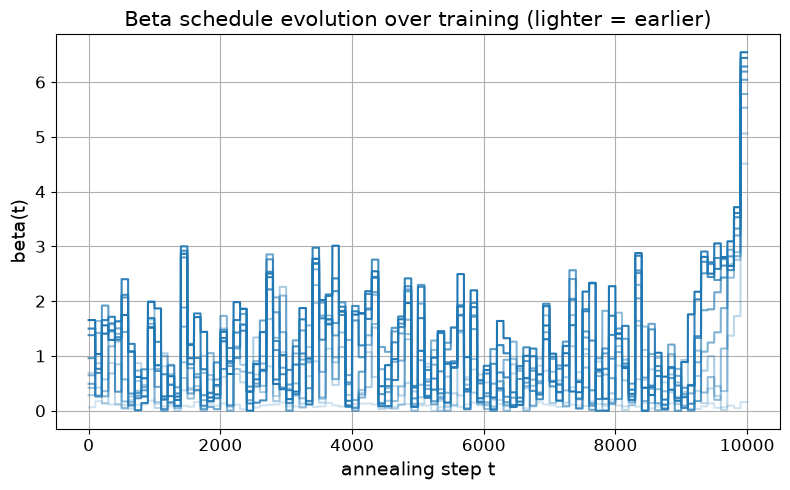

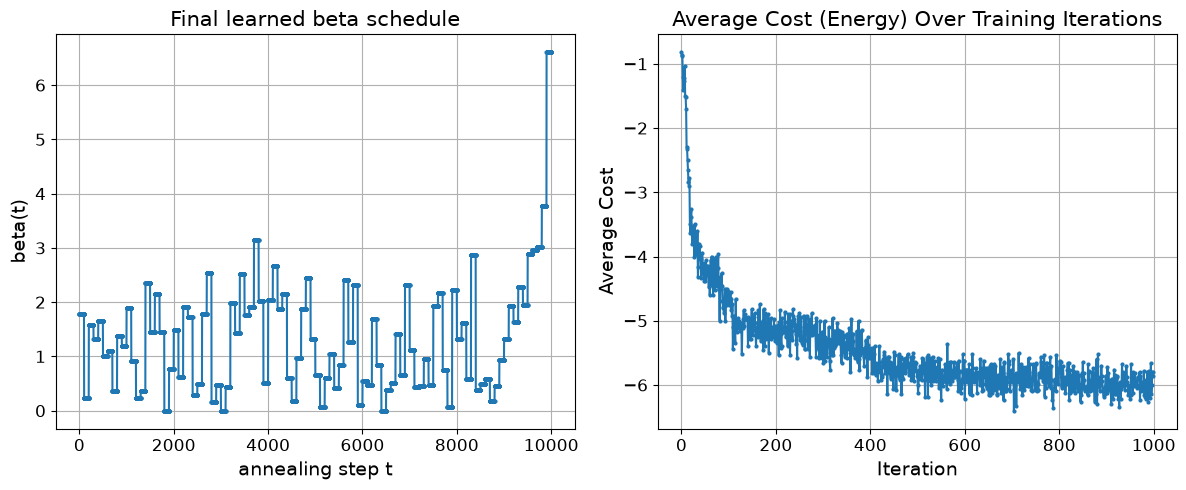

In [7]:
plt.figure(figsize=(8, 5))
for i, snap in enumerate(schedule_snapshots):
    alpha = 0.2 + 0.8 * (i / max(len(schedule_snapshots) - 1, 1))
    plt.plot(np.repeat(snap, block_size), color='C0', alpha=alpha)
plt.xlabel("annealing step t")
plt.ylabel("beta(t)")
plt.title("Beta schedule evolution over training (lighter = earlier)")
plt.grid(True)
plt.tight_layout()
plt.show()

# final schedule + cost convergence

beta_full = np.repeat(beta_schedule, block_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_full, marker='o', markersize=2)
axes[0].set_title("Final learned beta schedule")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].grid(True)

axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost (Energy) Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)

plt.tight_layout()
plt.show()